# Разведочный анализ данных

In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [168]:
df = pd.read_csv("../data/interim/train.csv", index_col=0)

In [169]:
df

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,description,state,lat,long,posting_date
0,reno / tahoe,28590,2016.0,subaru,wrx sti sedan 4d,good,NaN,other,57707.0,clean,other,NaN,sedan,blue,Carvana is the safer way to buy a car During t...,ca,33.779214,-84.411811,2021-05-02T05:00:56-0700
1,beaumont / port arthur,2000,1999.0,chevrolet,tracker,good,4 cylinders,gas,210000.0,clean,automatic,rwd,SUV,red,Today we got a very fun vehicle to drive. This...,tx,30.057265,-94.220770,2021-04-26T08:21:09-0500
2,baltimore,3100,2008.0,hyundai,elantra,NaN,4 cylinders,gas,184045.0,clean,automatic,fwd,sedan,purple,This 2008 Hyundai Elantra has been SOLD but ca...,md,39.433086,-76.343119,2021-04-20T06:11:14-0400
3,baltimore,30990,2014.0,ford,f150 supercrew cab fx4,good,NaN,other,67344.0,clean,other,4wd,pickup,orange,Carvana is the safer way to buy a car During t...,md,39.300000,-76.610000,2021-05-02T12:51:35-0400
4,fayetteville,6800,2010.0,toyota,scion xb,excellent,4 cylinders,gas,119400.0,clean,automatic,fwd,hatchback,white,"2010 Toyota Scion xB Hatchback, FINANCING AVAI...",ar,35.958944,-94.466286,2021-04-19T14:50:48-0500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189591,rhode island,32900,2018.0,jeep,wrangler unlimited,like new,6 cylinders,gas,62000.0,clean,automatic,4wd,SUV,black,Looking to sell my 2018 jeep wrangler 4 door. ...,ri,41.400700,-71.661500,2021-04-14T07:45:40-0400
189592,orlando,26990,2018.0,infiniti,q50 3.0t luxe sedan 4d,good,6 cylinders,gas,20193.0,clean,other,rwd,sedan,black,Carvana is the safer way to buy a car During t...,fl,28.500000,-81.370000,2021-04-29T21:21:02-0400
189593,"st louis, MO",11995,2011.0,chevrolet,avalanche,NaN,NaN,gas,180396.0,clean,automatic,rwd,pickup,white,Laura Chrysler Dodge Jeep Ram of Sullivan addr...,il,38.220447,-91.162972,2021-04-25T08:00:59-0500
189594,anchorage / mat-su,4200,2004.0,ford,taurus se,good,NaN,gas,114800.0,clean,automatic,fwd,hatchback,red,"2004 Ford Taurus SE runs great, 144,800 mi abo...",ak,61.203700,-149.744700,2021-04-30T19:04:54-0800


In [170]:
df.shape

(189596, 19)

In [171]:
nan_df = (df.isnull().mean() * 100).reset_index()
nan_df.columns = ["feature", "percentage"]
nan_df.sort_values('percentage', ascending=False, inplace=True)
nan_df

,feature,percentage
6,cylinders,37.892677
5,condition,35.492837
11,drive,29.095023
13,paint_color,27.565982
12,type,22.954071
3,manufacturer,4.335535
9,title_status,1.406675
4,model,1.347602
17,long,0.639781
16,lat,0.639781


In [172]:
df["price"].describe().apply(lambda x: f"{x:.2f}")

count    189596.00
mean      17863.58
std       14229.77
min         500.00
25%        6988.00
50%       13995.00
75%       25900.00
max      100000.00
Name: price, dtype: str

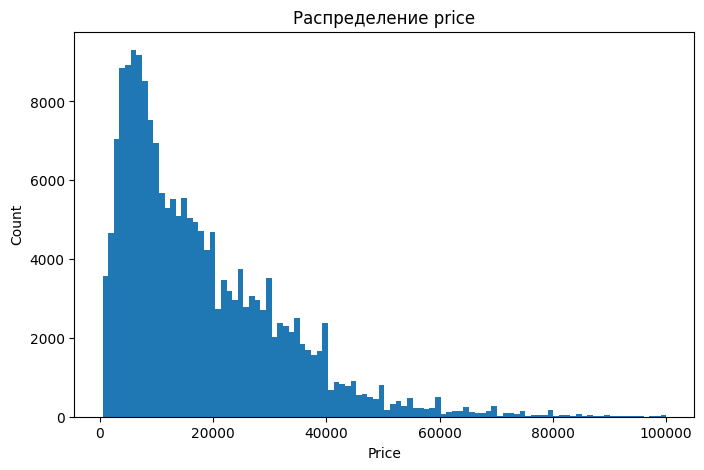

In [173]:
plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=100)
plt.title("Распределение price")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

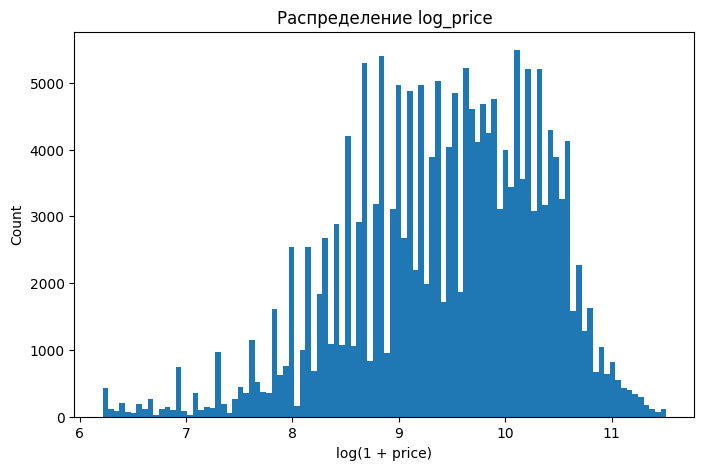

In [174]:
df["log_price"] = np.log1p(df["price"])

plt.figure(figsize=(8, 5))
plt.hist(df["log_price"], bins=100)
plt.title("Распределение log_price")
plt.xlabel("log(1 + price)")
plt.ylabel("Count")
plt.show()

In [175]:
df["year"].describe()

count    189030.000000
mean       2010.005576
std          10.533769
min        1900.000000
25%        2007.000000
50%        2013.000000
75%        2016.000000
max        2022.000000
Name: year, dtype: float64

In [176]:
df[df["year"] < 1960][["price", "year", "manufacturer", "model", "odometer"]].head(20)

,price,year,manufacturer,model,odometer
58,13500,1958.0,ford,custom 300,10000.0
84,39900,1933.0,NaN,Plymouth Sedan,35000.0
151,16850,1954.0,chevrolet,wagon,38000.0
179,15000,1957.0,volkswagen,beetle,9999999.0
211,12000,1956.0,pontiac,chieften,9999999.0
223,35900,1947.0,chevrolet,NaN,3550.0
274,1200,1955.0,ford,fairlane,1.0
289,7900,1938.0,jaguar,ss100,1000.0
334,12000,1925.0,NaN,1925 Model TT Dump Truck,1.0
335,46500,1939.0,ford,deluxe hardtop convertible,5708.0


In [177]:
df[df["year"] < 1960].shape

(1503, 20)

In [178]:
df = df[((df["year"] >= 1980))]

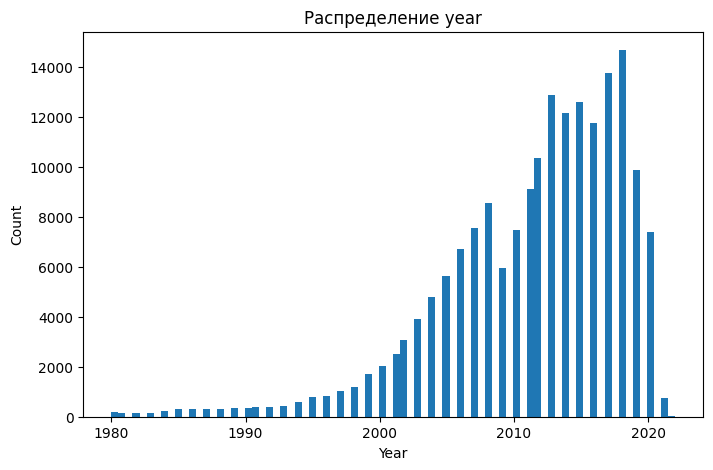

In [179]:
plt.figure(figsize=(8, 5))
plt.hist(df["year"].dropna(), bins=80)
plt.title("Распределение year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

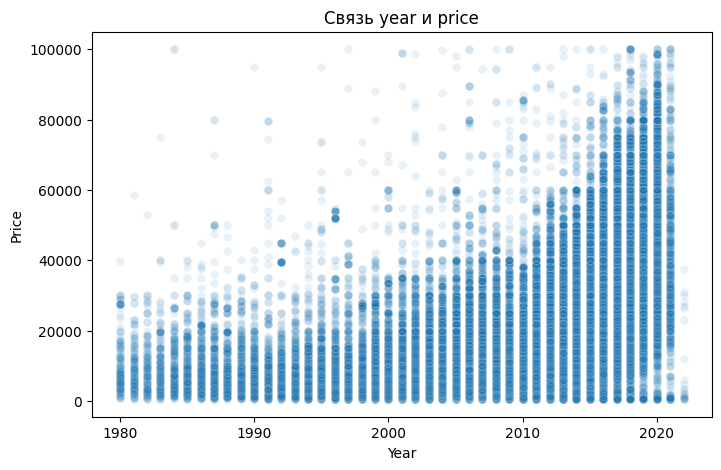

In [180]:
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="year",
    y="price",
    alpha=0.1
)

plt.title("Связь year и price")
plt.xlabel("Year")
plt.ylabel("Price")

plt.show()

In [181]:
df["year"] = df["year"].fillna(df["year"].mode()[0])

In [182]:
df["odometer"].describe().apply(lambda x: f"{x:.2f}")

count      183108.00
mean       103421.55
std        166419.88
min             0.00
25%         43092.75
50%         94475.50
75%        142100.00
max      10000000.00
Name: odometer, dtype: str

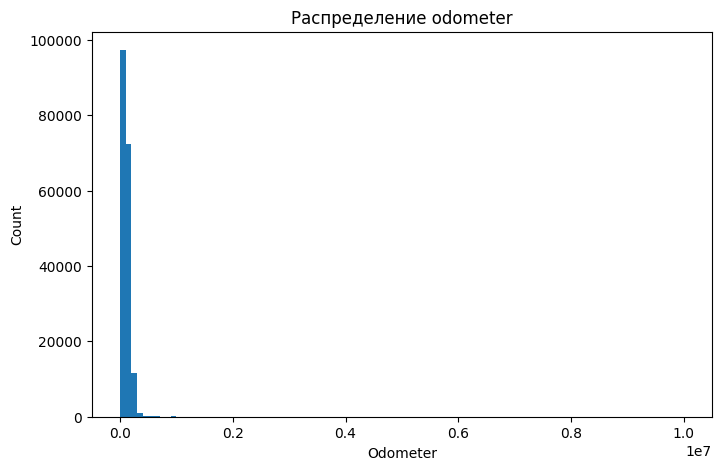

In [183]:
plt.figure(figsize=(8, 5))
plt.hist(df["odometer"].dropna(), bins=100)
plt.title("Распределение odometer")
plt.xlabel("Odometer")
plt.ylabel("Count")
plt.show()

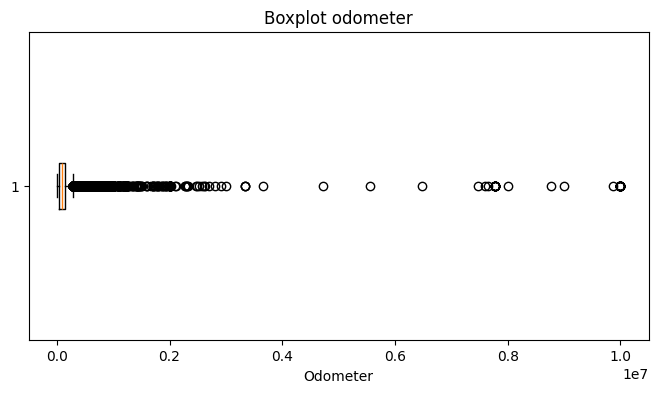

In [184]:
plt.figure(figsize=(8, 4))
plt.boxplot(df["odometer"].dropna(), vert=False)
plt.title("Boxplot odometer")
plt.xlabel("Odometer")
plt.show()

In [185]:
print("odometer = 0:", (df["odometer"] == 0).sum())
print("odometer > 500000:", (df["odometer"] > 500000).sum())

df[df["odometer"] > 500000][["price", "year", "manufacturer", "model", "odometer"]].head(20)

odometer = 0: 374
odometer > 500000: 561


,price,year,manufacturer,model,odometer
250,20850,2000.0,ford,NaN,525000.0
607,2200,2002.0,ford,f-150 xlt,555555.0
899,12500,1991.0,ram,2500,1000000.0
1356,17500,2014.0,NaN,freightliner cascadia,900000.0
1931,41000,2012.0,NaN,Peterbilt 389,1091331.0
2725,5900,2006.0,volvo,NaN,1019000.0
2752,30500,2014.0,NaN,freightliner cascadia,715200.0
3179,8900,1991.0,NaN,INTERNATIONAL 9800,790298.0
3391,52000,1996.0,NaN,Peterbilt 379,840000.0
3559,12500,2000.0,NaN,Freightliner,637127.0


In [186]:
df = df[
    ((df["odometer"] > 0) & (df["odometer"] <= 500000))
].copy()

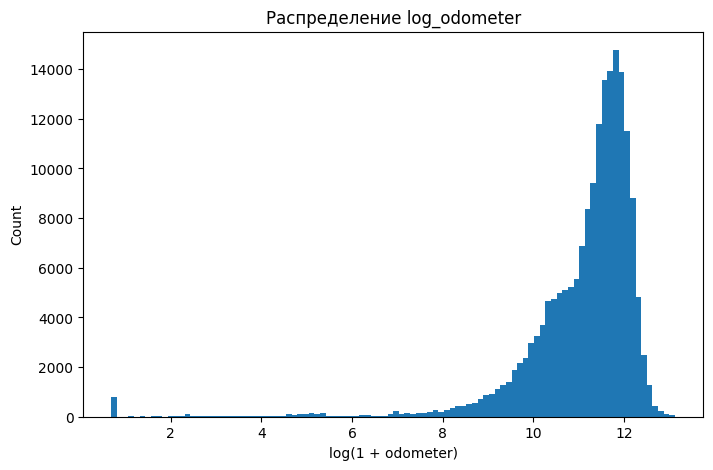

In [187]:
df["log_odometer"] = np.log1p(df["odometer"])

plt.figure(figsize=(8, 5))
plt.hist(df["log_odometer"].dropna(), bins=100)
plt.title("Распределение log_odometer")
plt.xlabel("log(1 + odometer)")
plt.ylabel("Count")
plt.show()

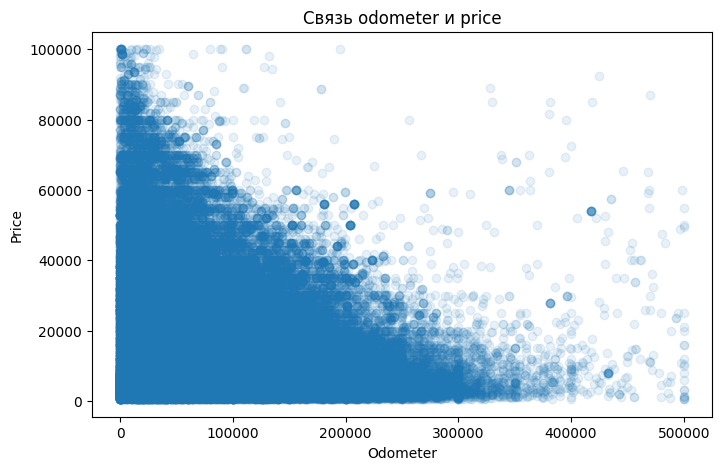

In [188]:
plt.figure(figsize=(8, 5))
plt.scatter(df["odometer"], df["price"], alpha=0.1)
plt.title("Связь odometer и price")
plt.xlabel("Odometer")
plt.ylabel("Price")
plt.show()

In [189]:
df["odometer"] = df["odometer"].fillna(df["odometer"].mean())

In [190]:
df["posting_date"] = pd.to_datetime(
    df["posting_date"],
    errors="coerce",
    utc=True
)

df["posting_year"] = df["posting_date"].dt.year
df["posting_month"] = df["posting_date"].dt.month

df = df.drop(columns=["posting_date"])

In [191]:
df["posting_year"].nunique()

1

In [192]:
df.drop(columns=["posting_year"], inplace=True)

In [193]:
df["posting_month"].nunique()

2

In [194]:
df.drop(columns=["posting_month"], inplace=True)

In [195]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

categorical_cols

C:\Users\Alex\AppData\Local\Temp\ipykernel_12872\2376633327.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


['region',
 'manufacturer',
 'model',
 'condition',
 'cylinders',
 'fuel',
 'title_status',
 'transmission',
 'drive',
 'type',
 'paint_color',
 'description',
 'state']

In [196]:
cardinality_table = pd.DataFrame({
    "column": categorical_cols,
    "unique_count": [df[col].nunique(dropna=True) for col in categorical_cols],
    "missing_percent": [df[col].isna().mean() * 100 for col in categorical_cols]
})

cardinality_table = cardinality_table.sort_values("unique_count", ascending=False)

display(cardinality_table)

,column,unique_count,missing_percent
11,description,174141,0.000000
2,model,20288,1.112679
0,region,404,0.000000
12,state,51,0.000000
1,manufacturer,42,3.432452
9,type,13,22.326031
10,paint_color,12,27.214241
4,cylinders,8,38.044606
3,condition,6,35.427863
6,title_status,6,1.334995


In [197]:
df["model"].value_counts().head(20)

model
f-150             3132
silverado 1500    2046
1500              1656
accord            1465
camry             1425
silverado         1416
civic             1344
altima            1208
escape            1174
wrangler          1162
tacoma            1099
explorer          1072
grand cherokee    1053
2500              1020
corolla            981
cr-v               896
mustang            882
focus              833
equinox            831
fusion             760
Name: count, dtype: int64

In [198]:
model_counts = df["model"].value_counts(dropna=False)

n_unique = df["model"].nunique(dropna=False)

result = {
    "всего уникальных": n_unique,
    "встречаются 1 раз": (model_counts == 1).sum(),
    "встречаются меньше 5 раз": (model_counts < 5).sum(),
    "встречаются меньше 10 раз": (model_counts < 10).sum(),
    "встречаются меньше 20 раз": (model_counts < 20).sum(),
    "встречаются меньше 50 раз": (model_counts < 50).sum(),
}

result

{'всего уникальных': 20289,
 'встречаются 1 раз': np.int64(11709),
 'встречаются меньше 5 раз': np.int64(16126),
 'встречаются меньше 10 раз': np.int64(17832),
 'встречаются меньше 20 раз': np.int64(18917),
 'встречаются меньше 50 раз': np.int64(19742)}

In [199]:
model_counts = df["model"].value_counts(dropna=True)
popular_models = model_counts[model_counts >= 20].index

df["model"] = df["model"].fillna("unknown")

df["model"] = df["model"].where(
    df["model"].isin(popular_models) | (df["model"] == "unknown"),
    "other"
)

In [200]:
df["model"].nunique(dropna=False)

1373

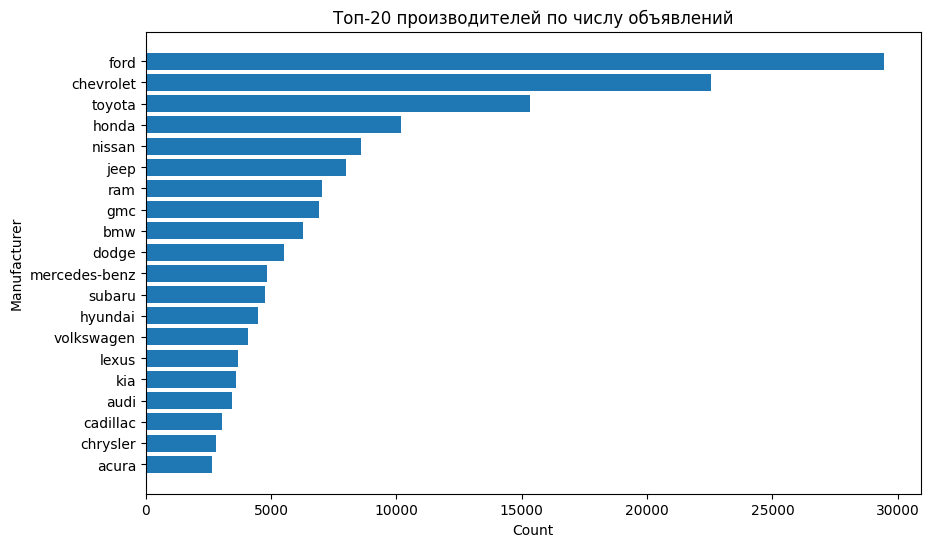

In [201]:
top_manufacturers = df["manufacturer"].value_counts().head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_manufacturers.index, top_manufacturers.values)
plt.title("Топ-20 производителей по числу объявлений")
plt.xlabel("Count")
plt.ylabel("Manufacturer")
plt.gca().invert_yaxis()
plt.show()

<Figure size 1200x600 with 0 Axes>

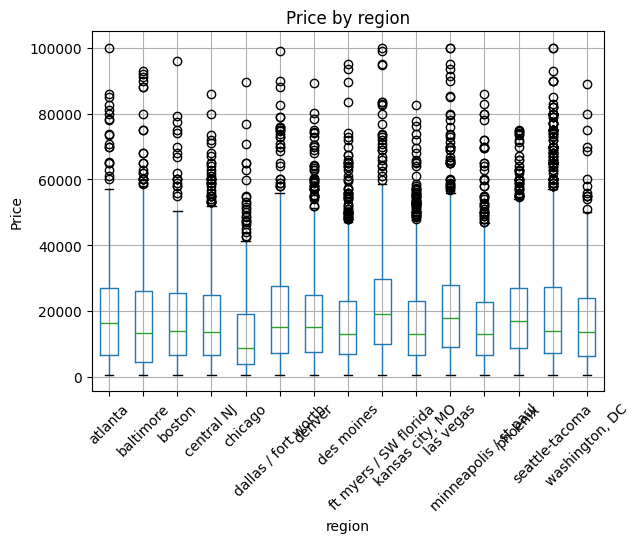

<Figure size 1200x600 with 0 Axes>

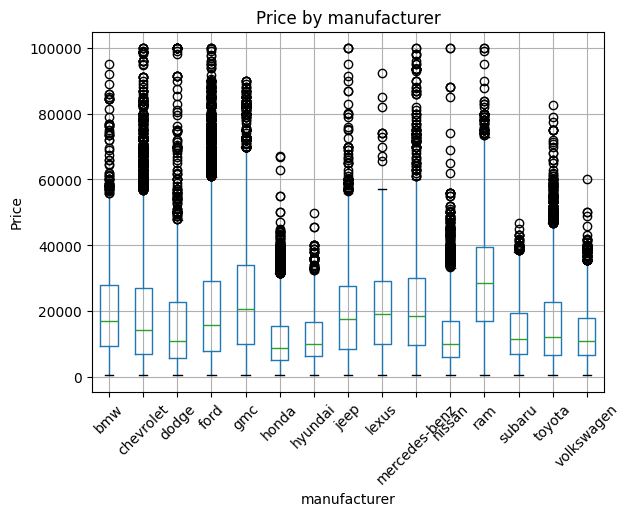

<Figure size 1200x600 with 0 Axes>

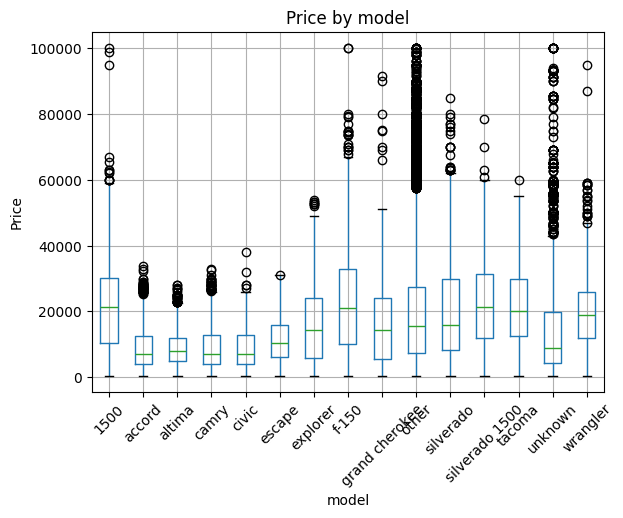

<Figure size 1200x600 with 0 Axes>

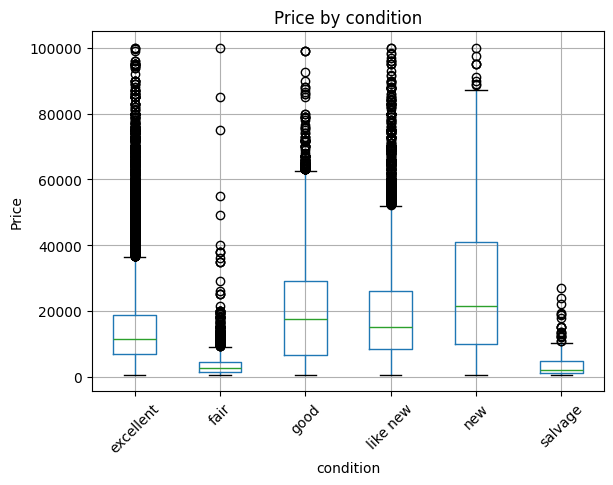

<Figure size 1200x600 with 0 Axes>

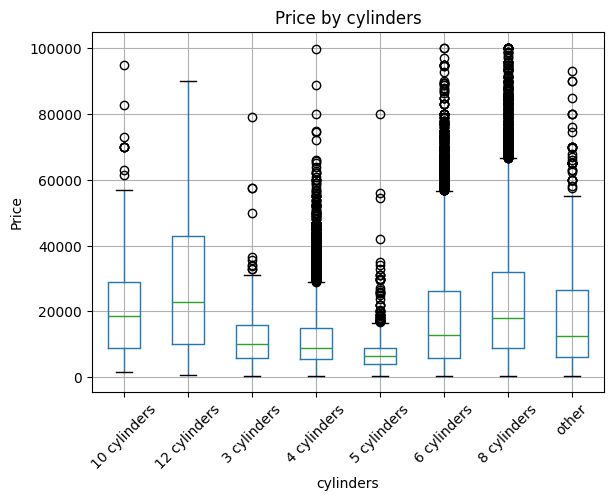

<Figure size 1200x600 with 0 Axes>

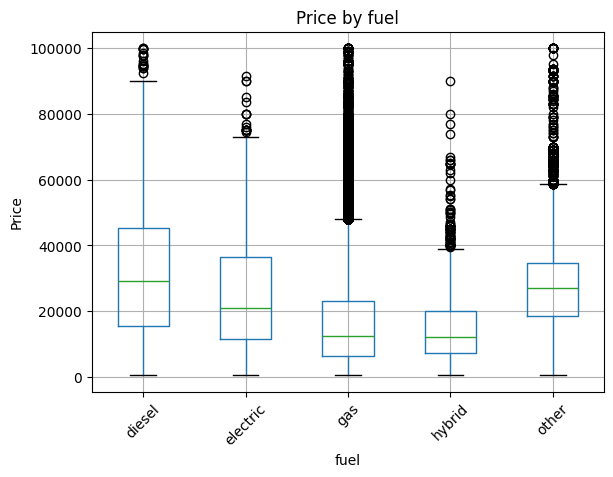

<Figure size 1200x600 with 0 Axes>

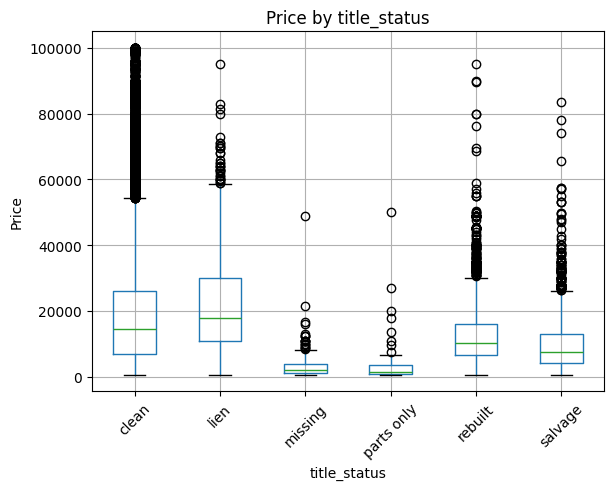

<Figure size 1200x600 with 0 Axes>

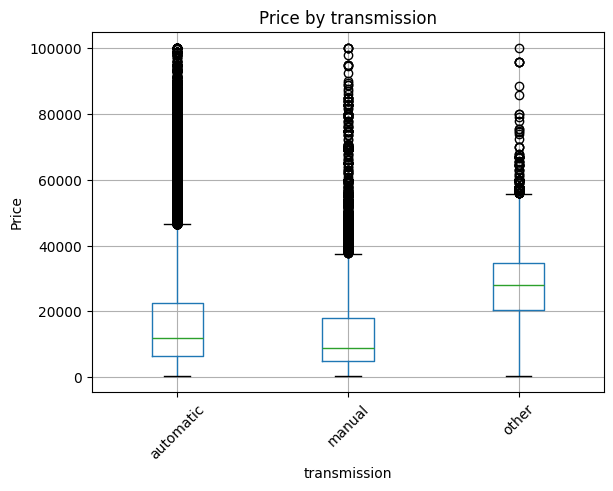

<Figure size 1200x600 with 0 Axes>

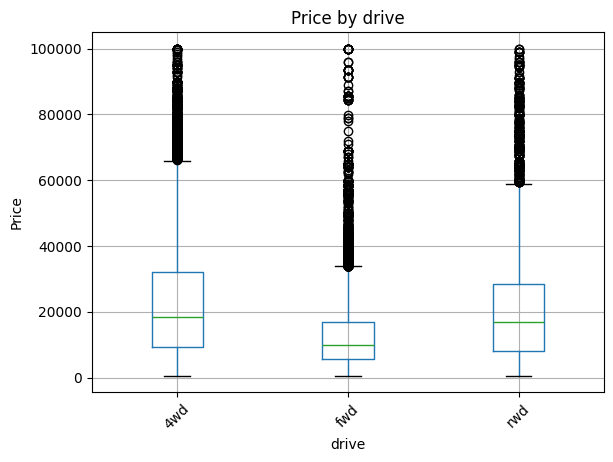

<Figure size 1200x600 with 0 Axes>

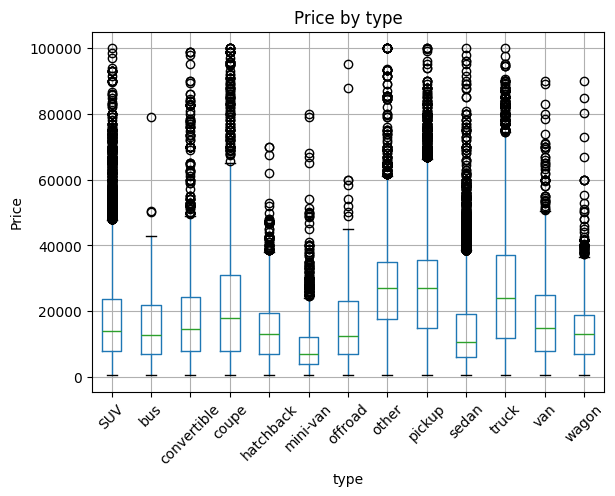

<Figure size 1200x600 with 0 Axes>

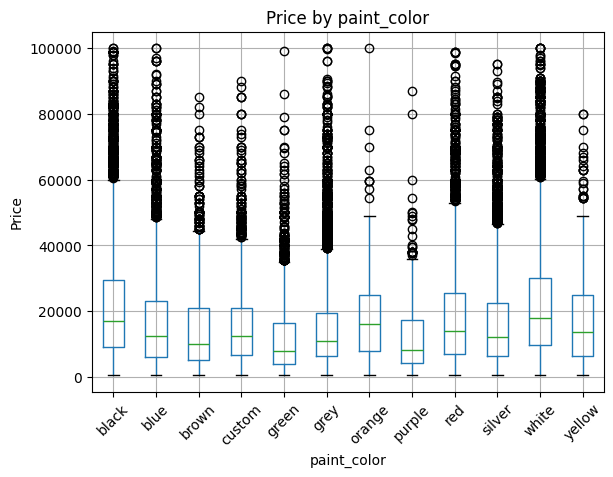

In [202]:
import matplotlib.pyplot as plt

categorical_features = [
    "region",
    "manufacturer",
    "model",
    "condition",
    "cylinders",
    "fuel",
    "title_status",
    "transmission",
    "drive",
    "type",
    "paint_color"
]

top_n = 15

for col in categorical_features:
    if col not in df.columns:
        print(f"Колонка {col} отсутствует в датасете")
        continue
    
    top_categories = df[col].value_counts().head(top_n).index
    
    plot_data = df[df[col].isin(top_categories)]
    
    plt.figure(figsize=(12, 6))
    plot_data.boxplot(column="price", by=col, rot=45)
    
    plt.title(f"Price by {col}")
    plt.suptitle("")
    plt.xlabel(col)
    plt.ylabel("Price")
    plt.show()

In [203]:
region_state_check = (
    df.groupby("region")["state"]
    .nunique()
    .sort_values(ascending=False)
)

display(region_state_check.head(20))

region
jackson                    3
lewiston / clarkston       2
cumberland valley          2
fayetteville               2
duluth / superior          2
huntington-ashland         2
columbus                   2
charleston                 2
jacksonville               2
monroe                     2
omaha / council bluffs     2
pullman / moscow           2
reno / tahoe               2
richmond                   2
rochester                  2
albany                     2
spokane / coeur d'alene    2
springfield                2
athens                     2
waco                       1
Name: state, dtype: int64

In [204]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

geo_df = df.dropna(subset=["lat", "long", "state"]).copy()

X_geo = geo_df[["lat", "long"]]
y_state = geo_df["state"]

clf = DecisionTreeClassifier(
    max_depth=10,
)

scores = cross_val_score(
    clf,
    X_geo,
    y_state,
    cv=5,
    scoring="accuracy"
)

print("Accuracy predicting state from lat/long:", scores.mean())

Accuracy predicting state from lat/long: 0.8659792926468158


In [205]:
df["lat_long_missing"] = (
    df["lat"].isna() | df["long"].isna()
).astype(int)

for col in ["lat", "long"]:
    df[col] = df[col].fillna(
        df.groupby("state")[col].transform("median")
    )

    df[col] = df[col].fillna(df[col].median())

Штат сильно коррелирует с координатами, поэтому чтобы снизить количество one hot колонок стоит попробовать удалить этот признак

In [206]:
df.drop(columns=["state"], inplace=True)

In [207]:
geo_df = df.dropna(subset=["lat", "long", "region"]).copy()

X_geo = geo_df[["lat", "long"]]
y_state = geo_df["region"]

clf = DecisionTreeClassifier(
    max_depth=10,
)

scores = cross_val_score(
    clf,
    X_geo,
    y_state,
    cv=5,
    scoring="accuracy"
)

print("Accuracy predicting region from lat/long:", scores.mean())

d:\VS code\Projects\PythonProjects\spbu_AI_technology_practice\project\project_venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Accuracy predicting region from lat/long: 0.2889560907685347


Признак region не дает сильной корреляции с координатами

In [208]:
from sklearn.cluster import KMeans

region_price = (
    df
    .assign(region=df["region"].fillna("unknown"))
    .groupby("region")["price"]
    .median()
    .reset_index()
)

kmeans = KMeans(
    n_clusters=10,
    n_init=10
)

region_price["region_cluster"] = kmeans.fit_predict(
    region_price[["price"]]
)

cluster_order = (
    region_price
    .groupby("region_cluster")["price"]
    .median()
    .sort_values()
    .index
)

cluster_map = {
    old_cluster: new_cluster
    for new_cluster, old_cluster in enumerate(cluster_order)
}

region_price["region_cluster"] = (
    region_price["region_cluster"]
    .map(cluster_map)
)

region_to_cluster = dict(
    zip(region_price["region"], region_price["region_cluster"])
)

df["region"] = df["region"].fillna("unknown")

df["region_price_cluster"] = (
    df["region"]
    .map(region_to_cluster)
    .astype("category")
)

df = df.drop(columns=["region"])

In [209]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

paint_color_price = (
    df
    .assign(paint_color=df["paint_color"].fillna("unknown"))
    .groupby("paint_color")["price"]
    .median()
    .reset_index()
)

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

paint_color_price["paint_color_cluster"] = kmeans.fit_predict(
    paint_color_price[["price"]]
)

cluster_order = (
    paint_color_price
    .groupby("paint_color_cluster")["price"]
    .median()
    .sort_values()
    .index
)

cluster_map = {
    old_cluster: new_cluster
    for new_cluster, old_cluster in enumerate(cluster_order)
}

paint_color_price["paint_color_cluster"] = (
    paint_color_price["paint_color_cluster"]
    .map(cluster_map)
)

paint_color_to_cluster = dict(
    zip(paint_color_price["paint_color"], paint_color_price["paint_color_cluster"])
)

df["paint_color"] = df["paint_color"].fillna("unknown")

df["paint_color_price_cluster"] = (
    df["paint_color"]
    .map(paint_color_to_cluster)
    .astype("category")
)

df = df.drop(columns=["paint_color"])

In [210]:
cols_to_fill = [
    "type",
    "drive",
    "transmission",
    "fuel",
    "condition",
    "manufacturer",
    "title_status"
]

for col in cols_to_fill:
    if col in df.columns:
        df[col] = df[col].fillna("unknown")

In [211]:
df["cylinders"].unique()

<StringArray>
[           nan,  '4 cylinders',  '6 cylinders',  '8 cylinders',
 '10 cylinders',        'other',  '3 cylinders',  '5 cylinders',
 '12 cylinders']
Length: 9, dtype: str

In [212]:
import numpy as np

cylinders_map = {
    "3 cylinders": 3,
    "4 cylinders": 4,
    "5 cylinders": 5,
    "6 cylinders": 6,
    "8 cylinders": 8,
    "10 cylinders": 10,
    "12 cylinders": 12,
    "other": 0
}

df["cylinders_other"] = (df["cylinders"] == "other").astype(int)

df["cylinders"] = (
    df["cylinders"]
    .map(cylinders_map)
    .fillna(0)
    .astype(int)
)

In [213]:
df["description"] = df["description"].fillna("")

In [214]:
df.drop(columns=["price"], inplace=True)

In [215]:
nan_df = (df.isnull().mean() * 100).reset_index()
nan_df.columns = ["feature", "percentage"]
nan_df.sort_values('percentage', ascending=False, inplace=True)
nan_df

,feature,percentage
0,year,0.0
1,manufacturer,0.0
2,model,0.0
3,condition,0.0
4,cylinders,0.0
5,fuel,0.0
6,odometer,0.0
7,title_status,0.0
8,transmission,0.0
9,drive,0.0


In [216]:
df

,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,description,lat,long,log_price,log_odometer,lat_long_missing,region_price_cluster,paint_color_price_cluster,cylinders_other
0,2016.0,subaru,wrx sti sedan 4d,good,0,other,57707.0,clean,other,unknown,sedan,Carvana is the safer way to buy a car During t...,33.779214,-84.411811,10.260847,10.963151,0,2,2,0
1,1999.0,chevrolet,other,good,4,gas,210000.0,clean,automatic,rwd,SUV,Today we got a very fun vehicle to drive. This...,30.057265,-94.220770,7.601402,12.254868,0,7,3,0
2,2008.0,hyundai,elantra,unknown,4,gas,184045.0,clean,automatic,fwd,sedan,This 2008 Hyundai Elantra has been SOLD but ca...,39.433086,-76.343119,8.039480,12.122941,0,2,0,0
3,2014.0,ford,f150 supercrew cab fx4,good,0,other,67344.0,clean,other,4wd,pickup,Carvana is the safer way to buy a car During t...,39.300000,-76.610000,10.341452,11.117584,0,2,4,0
4,2010.0,toyota,scion xb,excellent,4,gas,119400.0,clean,automatic,fwd,hatchback,"2010 Toyota Scion xB Hatchback, FINANCING AVAI...",35.958944,-94.466286,8.824825,11.690243,0,2,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189591,2018.0,jeep,wrangler unlimited,like new,6,gas,62000.0,clean,automatic,4wd,SUV,Looking to sell my 2018 jeep wrangler 4 door. ...,41.400700,-71.661500,10.401258,11.034906,0,2,4,0
189592,2018.0,infiniti,q50 3.0t luxe sedan 4d,good,6,gas,20193.0,clean,other,rwd,sedan,Carvana is the safer way to buy a car During t...,28.500000,-81.370000,10.203259,9.913141,0,1,4,0
189593,2011.0,chevrolet,avalanche,unknown,0,gas,180396.0,clean,automatic,rwd,pickup,Laura Chrysler Dodge Jeep Ram of Sullivan addr...,38.220447,-91.162972,9.392329,12.102915,0,3,4,0
189594,2004.0,ford,taurus se,good,0,gas,114800.0,clean,automatic,fwd,hatchback,"2004 Ford Taurus SE runs great, 144,800 mi abo...",61.203700,-149.744700,8.343078,11.650955,0,6,3,0


In [217]:
df.columns

Index(['year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'odometer', 'title_status', 'transmission', 'drive', 'type',
       'description', 'lat', 'long', 'log_price', 'log_odometer',
       'lat_long_missing', 'region_price_cluster', 'paint_color_price_cluster',
       'cylinders_other'],
      dtype='str')

In [218]:
df = pd.read_csv("../data/interim/train.csv", index_col=0)

In [219]:
df = df[((df["year"] >= 1980))]
df = df[
    ((df["odometer"] > 0) & (df["odometer"] <= 500000))
].copy()

In [220]:
df.to_csv("../data/interim/train_filtered.csv")